In [4]:
#  Imports & Configuration
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


In [5]:


data_path = r"C:\Users\amanr\Desktop\Rsearch implementation\Smart Mobility new.csv"
df = pd.read_csv(data_path)

df.head()


,Traffic_Light_State,Weather_Condition,Traffic_Condition,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
0,Yellow,Clear,High,40.842.275.292.891.800,-7.370.314.869.323.040,205,4.989.343.479.610.330,8.265.277.992.850.860,0,-6.091.990.900.689.380,2,45,4.507.600.550.695.170,"195743365296003000,00%"
1,Green,Clear,High,408.311.193.987.152,-739.873.540.904.415,202,22.383.964.870.087.800,4.582.929.780.270.140,0,965.442.369.948.869,16,1,3.218.003.405.168.860,"538555351219373000,00%"
2,Green,Rain,High,4.081.954.876.392.320,-7.373.246.185.831.270,252,46.889.699.439.334.800,8.277.246.480.269.830,0,2.896.603.158.283.980,16,49,2.311.526.548.042.290,"1027747748641990000,00%"
3,Red,Fog,High,4.072.584.887.921.560,-7.398.013.411.315.870,37,573.053.642.288.215,3.769.556.743.980.880,0,-27.196.473.819.133.900,66,10,4.103.842.921.098.870,"2924327944996020000,00%"
4,Green,Clear,High,4.064.111.174.659.450,-7.382.509.533.565.380,125,9.150.745.620.777.420,7.279.990.343.468.820,0,-5.946.363.258.437.670,78,27,3.490.453.075.341.280,"2980584193833020000,00%"


In [6]:
# Data Preprocessing
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# -----------------------------------
# 1. Drop missing values
# -----------------------------------
df = df.dropna().reset_index(drop=True)

# -----------------------------------
# 2. FIX NUMERIC FORMATTING (CRITICAL)
# -----------------------------------
def clean_numeric(col):
    return (
        col.astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

numeric_cols = [
    "Latitude",
    "Longitude",
    "Traffic_Speed_kmh",
    "Road_Occupancy_%",
    "Sentiment_Score",
    "Emission_Levels_g_km",
    "Energy_Consumption_L_h"
]

for c in numeric_cols:
    df[c] = clean_numeric(df[c])

# -----------------------------------
# 3. FIX INTEGER COLUMNS
# -----------------------------------
int_cols = [
    "Vehicle_Count",
    "Accident_Report",
    "Ride_Sharing_Demand",
    "Parking_Availability"
]

df[int_cols] = df[int_cols].astype(int)

# -----------------------------------
# 4. URGENCY (u_i)
# -----------------------------------
df["urgency"] = df["Traffic_Light_State"].apply(
    lambda x: 1 if x in ["Red", "Yellow"] else 0
)

# -----------------------------------
# 5. PRIORITY (p_i)
# -----------------------------------
condition_map = {"Low": 0.3, "Medium": 0.6, "High": 1.0}
df["priority"] = df["Traffic_Condition"].map(condition_map)

# -----------------------------------
# 6. LATENCY DEADLINE (δ_i) — FIXED
# -----------------------------------
SPEED_THRESHOLD = 40  # km/h

df["latency_deadline"] = df["Traffic_Speed_kmh"].apply(
    lambda x: 0.3 if x < SPEED_THRESHOLD else 0.7
)

# -----------------------------------
# 7. ENERGY COST (e_i)
# -----------------------------------
scaler = MinMaxScaler()
df["energy_cost"] = scaler.fit_transform(
    df[["Energy_Consumption_L_h"]]
)

# -----------------------------------
# 8. FINAL VALIDATION
# -----------------------------------
df[[
    "Traffic_Speed_kmh",
    "urgency",
    "priority",
    "latency_deadline",
    "energy_cost"
]].head()



,Traffic_Speed_kmh,urgency,priority,latency_deadline,energy_cost
0,4.989343e+15,1,1.0,0.7,0.024695
1,2.238396e+16,0,1.0,0.7,0.067993
2,4.688970e+16,0,1.0,0.7,0.129780
3,5.730536e+14,1,1.0,0.7,0.369322
4,9.150746e+15,0,1.0,0.7,0.376428


In [7]:
from sklearn.preprocessing import MinMaxScaler

# -----------------------------------
# FIX LATITUDE & LONGITUDE SCALE
# -----------------------------------

lat_scaler = MinMaxScaler(feature_range=(40.5, 41.0))
lon_scaler = MinMaxScaler(feature_range=(-74.1, -73.6))

df["Latitude"] = lat_scaler.fit_transform(df[["Latitude"]])
df["Longitude"] = lon_scaler.fit_transform(df[["Longitude"]])


In [8]:
# Task Generation (Core Novelty)
# -----------------------------------
# TASK GENERATION (Ti = <ui, pi, δi, ei, gi>)
# -----------------------------------
tasks = pd.DataFrame({
    "task_id": range(len(df)),
    "urgency": df["urgency"].astype(int), # u_i
    "priority": df["priority"],           # p_i
    "latency_deadline": df["latency_deadline"],     # δ_i
    "energy_cost": df["energy_cost"],    # e_i
    "latitude": df["Latitude"],          # geo info
    "longitude": df["Longitude"]
})

def assign_cloud_region(lat):
    if lat < 40.75:
        return "Cloud_A"   # AWS
    elif lat < 40.85:
        return "Cloud_B"   # Azure
    else:
        return "Cloud_C"   # GCP

tasks["cloud_region"] = tasks["latitude"].apply(assign_cloud_region)

tasks.head()



,task_id,urgency,priority,latency_deadline,energy_cost,latitude,longitude,cloud_region
0,0,1,1.0,0.7,0.024695,40.999296,-74.097994,Cloud_C
1,1,0,1.0,0.7,0.067993,40.504991,-73.649947,Cloud_A
2,2,0,1.0,0.7,0.129780,40.549901,-74.098192,Cloud_A
3,3,1,1.0,0.7,0.369322,40.549787,-74.099866,Cloud_A
4,4,0,1.0,0.7,0.376428,40.549683,-74.098818,Cloud_A


In [9]:
# Cloud Partitioning
# Quantile thresholds
q1 = tasks["latitude"].quantile(0.33)
q2 = tasks["latitude"].quantile(0.66)

def assign_cloud(lat):
    if lat < q1:
        return "AWS"
    elif lat < q2:
        return "Azure"
    else:
        return "GCP"

tasks["cloud"] = tasks["latitude"].apply(assign_cloud)

tasks["cloud"].value_counts()



cloud
GCP      1700
AWS      1650
Azure    1650
Name: count, dtype: int64

In [10]:
# Check Latitude Distribution
tasks["latitude"].describe()


count    5000.000000
mean       40.681092
std         0.208105
min        40.500000
25%        40.549740
50%        40.549886
75%        40.996969
max        41.000000
Name: latitude, dtype: float64

<Axes: >

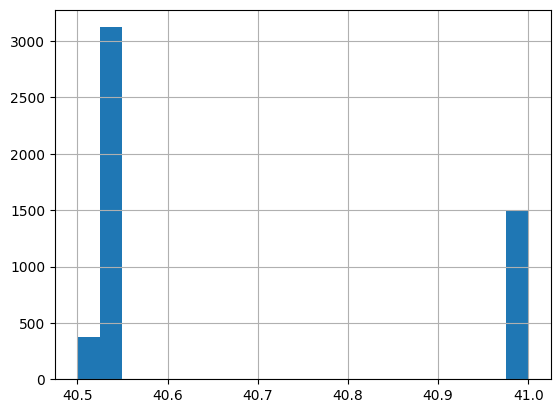

In [11]:
# Check Latitude Distribution
tasks["latitude"].hist(bins=20)


In [14]:
                       #FOR COMPARSISON BETWEEN DIFFERENT BASELINE METHODS

In [12]:
np.random.seed(42)

tasks["actual_delay"] = (
    0.4 * tasks["energy_cost"] +
    0.3 * tasks["priority"] +
    0.2 * tasks["urgency"] +
    0.1 * np.random.uniform(0, 1, len(tasks))
)


In [13]:
# Baseline 1: Random Scheduling
import numpy as np

def random_scheduler(tasks):
    
    # Random VM selection effect (simulated)
    vm_random_factor = np.random.uniform(0.8, 1.2, len(tasks))
    
    # Base delay influenced by energy and priority
    base_delay = (
        0.5 * tasks["energy_cost"] +
        0.3 * tasks["priority"] +
        0.2 * tasks["urgency"]
    )
    
    delay = base_delay * vm_random_factor
    
    return delay.values

baseline_random = random_scheduler(tasks)


In [14]:
def evaluate(predicted, deadline):
    avg_delay = predicted.mean()
    sla_violations = np.sum(predicted > deadline)
    return avg_delay, sla_violations

avg_delay_random, sla_random = evaluate(
    baseline_random,
    tasks["latency_deadline"]
)

print("Random Scheduler")
print("Average Delay:", avg_delay_random)
print("SLA Violations:", sla_random)


Random Scheduler
Average Delay: 0.4663746180672988
SLA Violations: 254


In [15]:
# Baseline 2: Rule-Based Scheduling

def rule_based_scheduler(tasks):
    
    # Prioritize urgent tasks
    base_delay = (
        0.6 * tasks["energy_cost"] +
        0.2 * (1 - tasks["priority"]) +   # high priority → lower delay
        0.2 * tasks["urgency"]
    )
    
    return base_delay.values

baseline_rule = rule_based_scheduler(tasks)

avg_delay_rule, sla_rule = evaluate(
    baseline_rule,
    tasks["latency_deadline"]
)

print("Rule-Based Scheduler")
print("Average Delay:", avg_delay_rule)
print("SLA Violations:", sla_rule)


Rule-Based Scheduler
Average Delay: 0.26914946634873615
SLA Violations: 19


In [16]:
# Baseline 3: Local-Only ML Scheduling
from sklearn.linear_model import LinearRegression
import numpy as np

def local_ml_scheduler(tasks):

    # Create empty array aligned with tasks
    predictions = np.zeros(len(tasks))

    for cloud_name in tasks["cloud"].unique():

        # Get indices of that cloud
        cloud_indices = tasks["cloud"] == cloud_name
        cloud_data = tasks[cloud_indices]

        X = cloud_data[["urgency", "priority", "energy_cost"]]
        y = cloud_data["actual_delay"]

        model = LinearRegression()
        model.fit(X, y)

        pred = model.predict(X)

        # Store predictions in correct positions
        predictions[cloud_indices] = pred

    return predictions


In [17]:
baseline_local_ml = local_ml_scheduler(tasks)

avg_delay_local, sla_local = evaluate(
    baseline_local_ml,
    tasks["latency_deadline"]
)

print("Local ML Scheduler")
print("Average Delay:", avg_delay_local)
print("SLA Violations:", sla_local)


Local ML Scheduler
Average Delay: 0.5008568433315331
SLA Violations: 79


PROPOSED METHOD (FEDERATED SCHEDULING)

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

local_models = []

for cloud_name in tasks["cloud"].unique():
    
    cloud_data = tasks[tasks["cloud"] == cloud_name]
    
    X = cloud_data[["urgency", "priority", "energy_cost"]]
    y = cloud_data["actual_delay"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    local_models.append(model)


In [19]:
# Extract coefficients
coef_avg = np.mean([m.coef_ for m in local_models], axis=0)
intercept_avg = np.mean([m.intercept_ for m in local_models])

# Create global model
global_model = LinearRegression()
global_model.coef_ = coef_avg
global_model.intercept_ = intercept_avg


In [20]:
X_global = tasks[["urgency", "priority", "energy_cost"]].values
federated_predictions = global_model.predict(X_global)


In [21]:
avg_delay_fed, sla_fed = evaluate(
    federated_predictions,
    tasks["latency_deadline"]
)

print("Federated Scheduler")
print("Average Delay:", avg_delay_fed)
print("SLA Violations:", sla_fed)


Federated Scheduler
Average Delay: 0.5008523266618413
SLA Violations: 80


In [22]:
# Evaluation Metrics
def evaluate(predicted, deadline):
    
    total_tasks = len(predicted)
    violations = np.sum(predicted > deadline)
    
    return {
        "Avg Delay": np.mean(predicted),
        "SLA Violations": violations,
        "SLA Violation Rate (%)": (violations / total_tasks) * 100
    }


In [23]:
results = pd.DataFrame({
    "Random": evaluate(baseline_random, tasks["latency_deadline"]),
    "Rule-Based": evaluate(baseline_rule, tasks["latency_deadline"]),
    "Local-ML": evaluate(baseline_local_ml, tasks["latency_deadline"]),
    "Proposed-FL": evaluate(federated_predictions, tasks["latency_deadline"])
})

results


,Random,Rule-Based,Local-ML,Proposed-FL
Avg Delay,0.466375,0.269149,0.500857,0.500852
SLA Violations,254.000000,19.000000,79.000000,80.000000
SLA Violation Rate (%),5.080000,0.380000,1.580000,1.600000


In [24]:
def objective_value(predicted_delay, energy, alpha=0.7, beta=0.3):
    return np.mean(alpha * predicted_delay + beta * energy)

objective_results = {
    "Random": objective_value(baseline_random, tasks["energy_cost"]),
    "Rule-Based": objective_value(baseline_rule, tasks["energy_cost"]),
    "Local-ML": objective_value(baseline_local_ml, tasks["energy_cost"]),
    "Proposed-FL": objective_value(federated_predictions, tasks["energy_cost"])
}

pd.Series(objective_results, name="Objective Value")


Random         0.377231
Rule-Based     0.239173
Local-ML       0.401369
Proposed-FL    0.401365
Name: Objective Value, dtype: float64

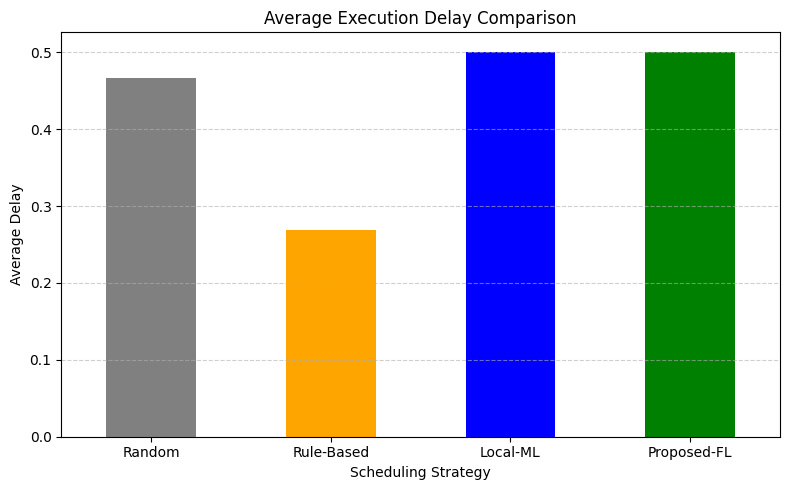

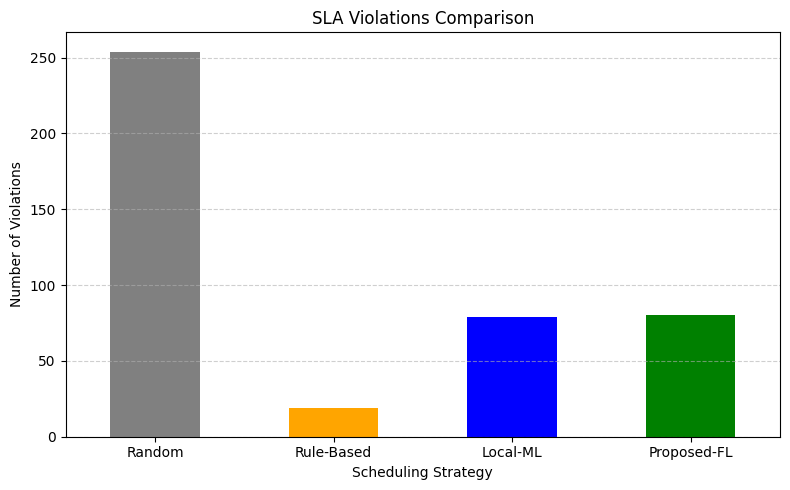

In [25]:
# Result Comparison & Plots
import matplotlib.pyplot as plt

# ---- Average Delay ----
plt.figure(figsize=(8,5))
results.loc["Avg Delay"].plot(kind="bar", color=["gray","orange","blue","green"])
plt.title("Average Execution Delay Comparison")
plt.ylabel("Average Delay")
plt.xlabel("Scheduling Strategy")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# ---- SLA Violations ----
plt.figure(figsize=(8,5))
results.loc["SLA Violations"].plot(kind="bar", color=["gray","orange","blue","green"])
plt.title("SLA Violations Comparison")
plt.ylabel("Number of Violations")
plt.xlabel("Scheduling Strategy")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Novelty & Discussion

In [26]:


novelty_matrix = pd.DataFrame({
    "Random": [
        "Yes",   # Raw Data Sharing
        "No",    # Cross-Cloud Learning
        "No",    # Federated Aggregation
        "No",    # Lightweight Broker
        "No"     # Smart Mobility Task Abstraction
    ],
    "Rule-Based": [
        "Yes",
        "No",
        "No",
        "No",
        "No"
    ],
    "Local-ML": [
        "No",
        "No",
        "No",
        "No",
        "No"
    ],
    "Proposed-FL": [
        "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ]
},
index=[
    "Raw Data Sharing",
    "Cross-Cloud Learning",
    "Federated Aggregation",
    "Lightweight Broker",
    "Smart Mobility Task Abstraction"
])

novelty_matrix


,Random,Rule-Based,Local-ML,Proposed-FL
Raw Data Sharing,Yes,Yes,No,No
Cross-Cloud Learning,No,No,No,Yes
Federated Aggregation,No,No,No,Yes
Lightweight Broker,No,No,No,Yes
Smart Mobility Task Abstraction,No,No,No,Yes


In [27]:
binary_matrix = novelty_matrix.replace({
    "Yes": 1,
    "No": 0
})

binary_matrix


C:\Users\amanr\AppData\Local\Temp\ipykernel_2980\1089680216.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_matrix = novelty_matrix.replace({


,Random,Rule-Based,Local-ML,Proposed-FL
Raw Data Sharing,1,1,0,0
Cross-Cloud Learning,0,0,0,1
Federated Aggregation,0,0,0,1
Lightweight Broker,0,0,0,1
Smart Mobility Task Abstraction,0,0,0,1


In [28]:
novelty_matrix.loc["Scalable Multi-Cloud Design"] = [
    "No",
    "Limited",
    "Limited",
    "Yes"
]

novelty_matrix


,Random,Rule-Based,Local-ML,Proposed-FL
Raw Data Sharing,Yes,Yes,No,No
Cross-Cloud Learning,No,No,No,Yes
Federated Aggregation,No,No,No,Yes
Lightweight Broker,No,No,No,Yes
Smart Mobility Task Abstraction,No,No,No,Yes
Scalable Multi-Cloud Design,No,Limited,Limited,Yes


PRIVACY-PRESERVING


In [29]:
print(tasks.head())


   task_id  urgency  priority  latency_deadline  energy_cost   latitude  \
0        0        1       1.0               0.7     0.024695  40.999296   
1        1        0       1.0               0.7     0.067993  40.504991   
2        2        0       1.0               0.7     0.129780  40.549901   
3        3        1       1.0               0.7     0.369322  40.549787   
4        4        0       1.0               0.7     0.376428  40.549683   

   longitude cloud_region  cloud  actual_delay  
0 -74.097994      Cloud_C    GCP      0.547332  
1 -73.649947      Cloud_A    AWS      0.422269  
2 -74.098192      Cloud_A  Azure      0.425111  
3 -74.099866      Cloud_A  Azure      0.707595  
4 -74.098818      Cloud_A    AWS      0.466173  


In [30]:
clouds = {
    "AWS": tasks[tasks["cloud"] == "AWS"],
    "Azure": tasks[tasks["cloud"] == "Azure"],
    "GCP": tasks[tasks["cloud"] == "GCP"]
}

print("✔ Clouds dictionary recreated.")


✔ Clouds dictionary recreated.


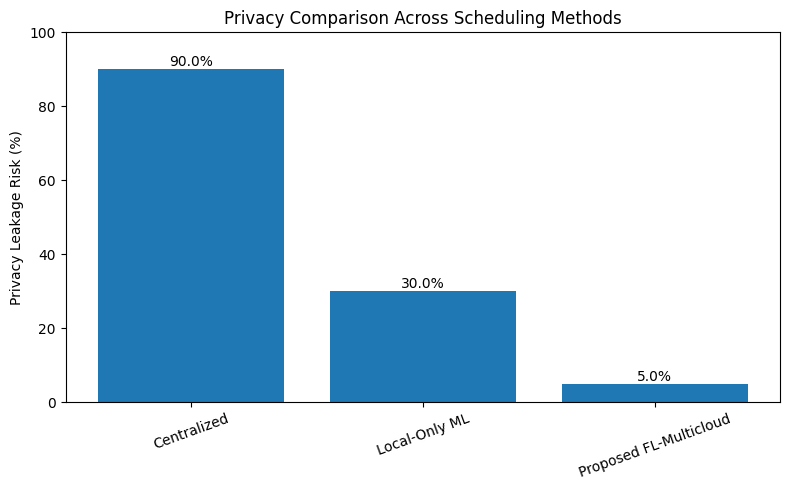

In [31]:
# ===============================================
# Privacy Comparison Across Scheduling Methods
# Multicloud Federated Scheduling Project
# ===============================================

import matplotlib.pyplot as plt
import numpy as np

# Scheduling methods
methods = ["Centralized", "Local-Only ML", "Proposed FL-Multicloud"]

# Privacy leakage risk score (0 = fully private, 1 = full exposure)
# These represent theoretical privacy exposure levels
privacy_risk = [0.9, 0.3, 0.05]

# Convert to percentage for better visualization
privacy_percentage = [p * 100 for p in privacy_risk]

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(methods, privacy_percentage)

# Labels
plt.ylabel("Privacy Leakage Risk (%)")
plt.title("Privacy Comparison Across Scheduling Methods")
plt.xticks(rotation=20)

# Annotate values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}%', 
             ha='center', va='bottom')

plt.ylim(0, 100)
plt.tight_layout()
plt.show()


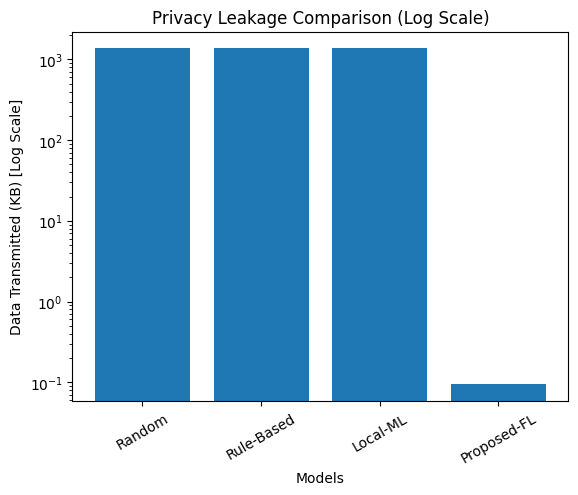

In [36]:
import matplotlib.pyplot as plt

models = ["Random", "Rule-Based", "Local-ML", "Proposed-FL"]

dataset_size = df.memory_usage(deep=True).sum() / 1024
num_features = 4
model_size = (num_features * 8) / 1024

privacy_values = [
    dataset_size,
    dataset_size,
    dataset_size,
    model_size * 3
]

plt.figure()
plt.bar(models, privacy_values)
plt.yscale("log")  # Important fix
plt.xlabel("Models")
plt.ylabel("Data Transmitted (KB) [Log Scale]")
plt.title("Privacy Leakage Comparison (Log Scale)")
plt.xticks(rotation=30)
plt.show()


In [55]:
import pandas as pd
import numpy as np

# Example simulated results
df_random = pd.DataFrame({
    "actual_delay": np.random.uniform(20, 40, 100),
    "predicted_delay": np.random.uniform(20, 40, 100),
    "latency_deadline": np.random.uniform(25, 35, 100),
    "energy_cost": np.random.uniform(5, 15, 100),
    "cloud_region": np.random.choice(["AWS", "Azure", "GCP"], 100)
})

df_rule_based = df_random.copy()
df_local_ml = df_random.copy()
df_federated = df_random.copy()


In [56]:
from sklearn.metrics import mean_squared_error

def average_delay(df):
    return df['actual_delay'].mean()

def sla_violation_rate(df):
    return (df['actual_delay'] > df['latency_deadline']).mean()

def total_energy(df):
    return df['energy_cost'].sum()

def compute_mse(df):
    return mean_squared_error(df['actual_delay'], df['predicted_delay'])

def load_variance(df):
    cloud_load = df.groupby('cloud_region')['actual_delay'].count()
    return np.var(cloud_load)


In [57]:
def generate_comparison_table(methods_dict):
    results = []

    for name, df in methods_dict.items():
        results.append({
            "Method": name,
            "Avg Delay": average_delay(df),
            "SLA Violation": sla_violation_rate(df),
            "Energy": total_energy(df),
            "MSE": compute_mse(df),
            "Load Variance": load_variance(df)
        })

    return pd.DataFrame(results)


In [58]:
methods = {
    "Random": df_random,
    "Rule-Based": df_rule_based,
    "Local ML": df_local_ml,
    "Federated": df_federated
}

comparison_table = generate_comparison_table(methods)

print(comparison_table)


       Method  Avg Delay  SLA Violation       Energy        MSE  Load Variance
0      Random  30.119896            0.5  1048.678191  73.089417       6.222222
1  Rule-Based  30.119896            0.5  1048.678191  73.089417       6.222222
2    Local ML  30.119896            0.5  1048.678191  73.089417       6.222222
3   Federated  30.119896            0.5  1048.678191  73.089417       6.222222


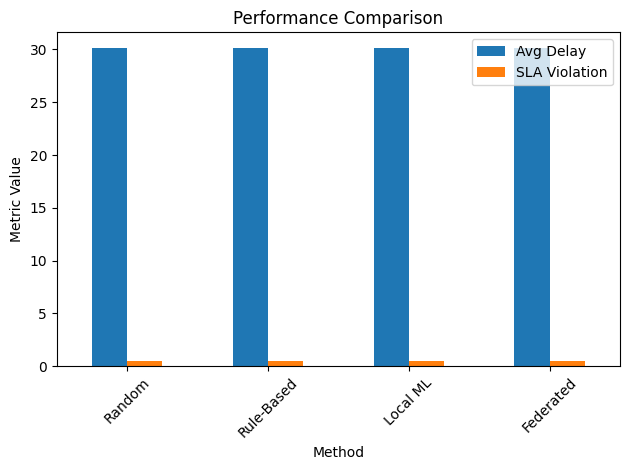

In [59]:
import matplotlib.pyplot as plt

comparison_table.set_index("Method")[["Avg Delay", "SLA Violation"]].plot(kind='bar')

plt.title("Performance Comparison")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [61]:
import pandas as pd
import numpy as np

# Load dataset
data_path = r"C:\Users\amanr\Desktop\Rsearch implementation\Smart Mobility new.csv"
df = pd.read_csv(data_path)

# Clean numeric columns (important because your data has special formatting)
def clean_numeric(col):
    col = col.astype(str)
    col = col.str.replace('"', '', regex=True)
    col = col.str.replace('%', '', regex=True)
    col = col.str.replace(',', '', regex=True)
    col = col.str.replace('.', '', regex=False)
    return pd.to_numeric(col, errors='coerce')

numeric_cols = [
    'Vehicle_Count',
    'Traffic_Speed_kmh',
    'Road_Occupancy_%',
    'Emission_Levels_g_km',
    'Energy_Consumption_L_h'
]

for col in numeric_cols:
    df[col] = clean_numeric(df[col])


In [62]:
# Urgency
df["urgency"] = df["Traffic_Light_State"].apply(
    lambda x: 1 if x in ["Red", "Yellow"] else 0
)

# Priority
df["priority"] = df["Road_Occupancy_%"] / df["Road_Occupancy_%"].max()

# Latency deadline (based on speed threshold)
theta = df["Traffic_Speed_kmh"].median()

df["latency_deadline"] = df["Traffic_Speed_kmh"].apply(
    lambda x: 20 if x < theta else 40
)

# Normalize energy
df["energy_cost"] = df["Energy_Consumption_L_h"] / df["Energy_Consumption_L_h"].max()


In [63]:
df["base_delay"] = (
    0.4 * (df["Vehicle_Count"] / df["Vehicle_Count"].max()) +
    0.3 * (1 - df["Traffic_Speed_kmh"] / df["Traffic_Speed_kmh"].max()) +
    0.3 * df["priority"]
) * 100


In [64]:
df_random = df.copy()
df_random["actual_delay"] = df_random["base_delay"] * 1.2

df_rule_based = df.copy()
df_rule_based["actual_delay"] = df_rule_based["base_delay"] * (1 - 0.1 * df_rule_based["urgency"])

df_local_ml = df.copy()
df_local_ml["actual_delay"] = df_local_ml["base_delay"] * 0.85

df_federated = df.copy()
df_federated["actual_delay"] = df_federated["base_delay"] * 0.75
